In [1]:
import sys
sys.path.append("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo")

from datasets.llff_dataset import LLFFDataset

In [2]:
import yaml

with open("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/configs/test.yaml") as f:
    cfg = yaml.load(f, Loader=yaml.FullLoader)
    cfg['device'] = 'cuda:3'
    
cfg['dataset']['base_dir'] = '/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/data/nerf_llff_data/fern'
dset = LLFFDataset(cfg['dataset'])

/home/diya/anaconda3/envs/tensorRT_JY/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [3]:
sp = dset.get_spiral_poses(n_views=10)

In [4]:
import sys
sys.path.append("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo")

from nerf.models import nerf
from nerf.models import build_model
from nerf.engines import build_engine
import torch


In [5]:
state_dict = torch.load("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/ckpts/fern/20240911-000301/ckpt_12000.pt", map_location='cuda:3')

In [6]:
# model = nerf.NeRF()

model = build_engine(cfg)

In [7]:
model.load_state_dict(state_dict)

Loaded state dict from epoch 12000


In [9]:
out = model.render_spiral(dset, batch_size=8192, n_views=10, render_train=False)

10 images will be rendered.


Rendering...:   0%|                                                          | 0/10 [00:00<?, ?it/s]

Rendering...: 100%|█████████████████████████████████████████████████| 10/10 [01:54<00:00, 11.46s/it]


In [10]:
out[0].shape, out[0].min(), out[0].dtype

(torch.Size([1, 190512, 3]), tensor(0.0426), torch.float32)

In [11]:
sp[:, :3, :4].min(), sp[:, :3, :4].max(), dset.poses.min(), dset.poses.max()

(-0.99999243, 0.99969417, tensor(-1.0000), tensor(1.0000))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 503.5, 377.5, -0.5)

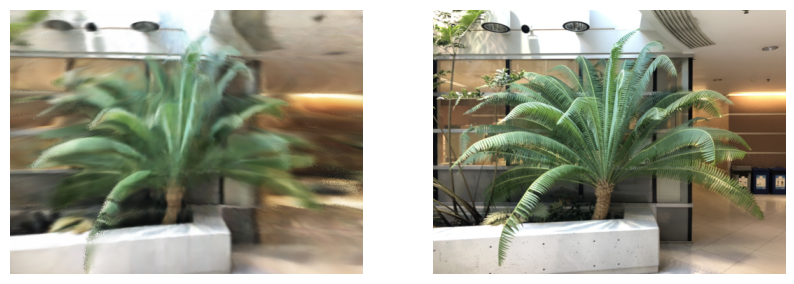

In [17]:
import matplotlib.pyplot as plt

H, W = dset.get_H(), dset.get_W()

idx = 4

sample = out[idx].view(-1, H, W, 3)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(sample[0])
plt.axis("off")
plt.subplot(122)
plt.imshow(dset.images[idx].permute(1, 2, 0))
plt.axis("off")

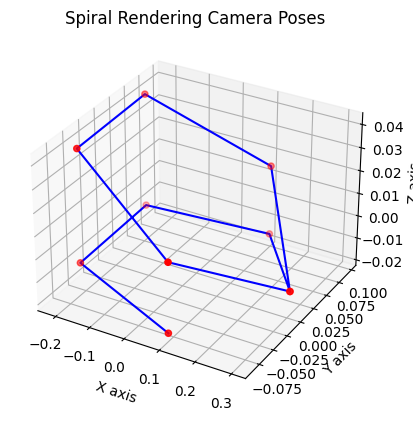

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_spiral_poses(poses):
    """
    Visualize the camera positions in 3D space for spiral rendering.
    Args:
        poses: np.array of shape (n_views, 3, 5) containing the camera extrinsics.
    """
    # Extract the camera positions (translation part)
    camera_positions = poses[:, :3, 3]  # Assuming translation is stored in the last column
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the camera positions
    ax.scatter(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2], c='r', marker='o')
    
    # Optionally, you can draw lines between consecutive camera positions to visualize the spiral
    ax.plot(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2], color='blue')
    
    # Label axes
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    
    plt.title('Spiral Rendering Camera Poses')
    plt.show()

# Example usage
# Assuming poses is a numpy array of shape (n_views, 3, 5)
# Replace this with your actual poses data
visualize_spiral_poses(sp[:, :3, :4])


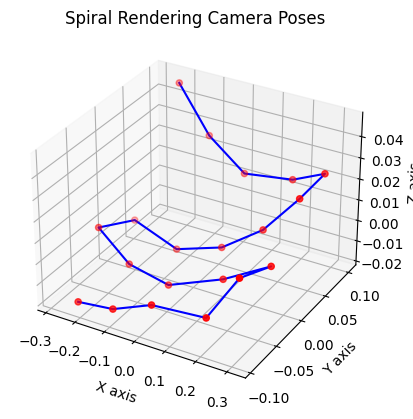

In [12]:
visualize_spiral_poses(np.array(dset.poses))

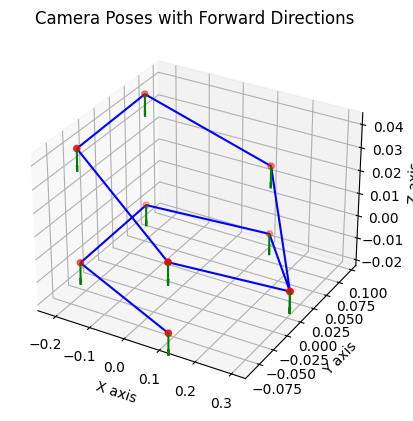

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_camera_poses_with_directions(poses):
    """
    Visualize the camera positions and forward directions in 3D space for spiral rendering.
    
    Args:
        poses: np.array of shape (n_views, 3, 5) containing the camera extrinsics.
    """
    # Extract the camera positions (translation part)
    camera_positions = poses[:, :3, 3]  # Assuming translation is stored in the last column
    
    # Extract the forward directions (3rd column of the 3x3 rotation matrix)
    forward_directions = poses[:, :3, 2]  # Assuming the 3rd column of the 3x3 matrix is the forward direction

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the camera positions
    ax.scatter(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2], c='r', marker='o')
    
    # Plot lines between consecutive camera positions to show the spiral path
    ax.plot(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2], color='blue')
    
    # Plot camera forward directions as quivers (arrows)
    ax.quiver(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2],
              forward_directions[:, 0], forward_directions[:, 1], forward_directions[:, 2],
              length=0.01, normalize=True, color='green')

    # Label axes
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    
    plt.title('Camera Poses with Forward Directions')
    plt.show()

# Example usage
# Replace this with your actual pose data, shaped (n_views, 3, 5)

visualize_camera_poses_with_directions(sp)


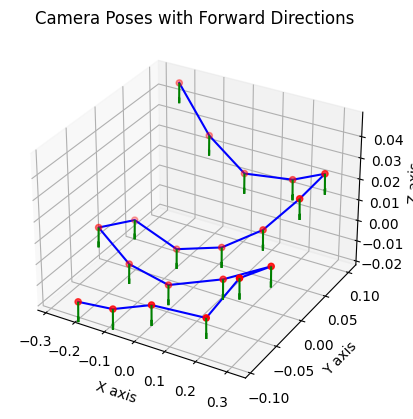

In [20]:
visualize_camera_poses_with_directions(np.array(dset.poses))

In [21]:
images = [o.view(-1, H, W, 3)[0] for o in out]

In [23]:
images[1].shape

torch.Size([378, 504, 3])

In [26]:
import cv2
import numpy as np
import os

def images_to_video(images, output_video_path, fps=30):
    height, width = images[0].shape[:2]

    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # You can change this to other codecs, like 'XVID' for .avi
    video = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    # Loop through all images and add them to the video
    for image in images:
        image = (np.array(image) * 255).astype(np.uint8)
        
        # Ensure image is in correct color format (BGR for OpenCV)
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        video.write(image)

    # Release the video writer
    video.release()

# Example usage
output_video_path = './output_video.mp4'  # Output video file path
images_to_video(images, output_video_path, fps=30)
